# Introduction

This program implements functionalities related to zone plates. To use it, the program should be converted into a script (`zone_plate.py`) and executed as a module.  

The implementation consists of multiple classes:  
**ZonePlate**: Handles basic settings and general methods.  
**ZonePlateVisualizer**: Responsible for visualizing the configuration of the zone plate.  
**FieldIntensityCalculator**: Calculates the field and intensity of light at the focal plane after passing through the zone plate.  
**FigureOfMeritCalculator**: Calculates the FoM of the zone plate based on the field or intensity.  

# Optical System
<img src="./optical_system.png" width="500" height="250" style="display:block; margin:auto;">

## Debye-Wolf Theory   

We use the **Debye–Wolf theory** (Eq. 1) to calculate the field distribution of this optical system at the focal plane. In Eq. 1, $\text{ring}$ correspond to the phase of the zone plate, where a value of 1 represents a phase of 0 and –1 represents a phase of π. (Eq. 2)

$$
E(r) = \sum_{n=1}^N \text{ring}_n \frac{2\pi}{\lambda} \int_{\theta_{n-1}}^{\theta_{n}} \sqrt{\cos\theta} J_0(kr\sin\theta) \sin\theta \mathrm{d}\theta
\tag{1}
$$

$$
\text{ring}_n = 1 \, \text{or} \, -1
\tag{2}
$$

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special, stats

In [2]:
class ZonePlate:
    """
    Only perform the basic settings and general methods
    """
    
    def __init__(
            self,
            multiple=8.0,
            resolution=2_000,
            wavelength=0.53,
            NA=0.95,
        ):
        self.multiple   = multiple
        self.resolution = resolution
        self.wavelength = wavelength
        self.NA         = NA

        self.rings = None
        self.k     = 2 * np.pi / wavelength
        self.r_vec = np.linspace(0, multiple, resolution)    # Unit: wavelength
        
        # Create internal components
        self.visualizer = ZonePlateVisualizer(self)
        self.field_intensity_calc = FieldIntensityCalculator(self)
        self.figure_of_merit_calc = FigureOfMeritCalculator(self)

    def update_field_table(self):
        # Define folder path
        self.field_table_folder_name = "field_tables"
        os.makedirs(self.field_table_folder_name, exist_ok=True)
        self.field_table_file_name = f"field_table_{self.rings}_{self.multiple}_{self.resolution}_{self.wavelength}_{self.NA}.npy"    # Filename should include: rings, multiple, resolution, wavelength, NA
        self.field_table_path = os.path.join(self.field_table_folder_name, self.field_table_file_name)
        # Load field table if it already exists
        self.field_table = None
        if os.path.exists(self.field_table_path):
            self.field_table = np.load(self.field_table_path)
    
    def set_config(self, config):
        self.config = config
        if (self.rings != self.config.shape[0]):
            self.rings = self.config.shape[0]
            self.update_field_table()

    def mul2idx(self, mul):
        return int( mul * self.resolution / self.multiple )

    def idx2mul(self, idx):
        return idx * self.multiple / self.resolution

In [1]:
class ZonePlateVisualizer:
    pass

In [3]:
class FieldIntensityCalculator:
    """
    Calculate the field and intensity using the Debye-Wolf theorem.

    Test paper configuration notes:
    - Switch the "sine_ls" definition in the method `generate_field_table`, 
      and the "config_processed" definition in the method `calc_field` for testing different setups.
    - The parameter "config" in the parent class method `set_config` 
      is restricted to be a 1D array of 30 elements when called.
    """
    
    def __init__(self, zone_plate):
        self.zone_plate = zone_plate

    def generate_field_table(self, path=None):
        N = self.zone_plate.rings
        
        def integrand(theta, k, r):
            """
            theta : variable of integration
            """
            return np.sqrt(np.cos(theta)) * special.j0(k*r*np.sin(theta)) * np.sin(theta)
            
        sine_ls = np.linspace(0, self.zone_plate.NA, N+1)    # N rings require N+1 points
        # sine_ls = np.array([0, 0.0317, 0.0635, 0.0955, 0.1291, 0.1614, 0.1941, 0.2271, 0.2602, 0.2928, 0.3247, 0.3576, 0.3899, 0.4222, 0.4544, 0.487, 0.5196, 0.5517, 0.5835, 0.6154, 0.647, 0.6796, 0.7113, 0.7435, 0.7742, 0.8063, 0.8357, 0.8676, 0.8949, 0.9244, 0.95])
        theta_ls = np.arcsin(sine_ls)

        self.zone_plate.field_table = np.zeros(shape=(N, self.zone_plate.r_vec.shape[0]), dtype=np.float64)    # Since the field result is purely real, we use a real-valued array
        for n in range(1, N+1):
            for r_idx in range(self.zone_plate.r_vec.shape[0]):
                integral, err = integrate.quad(integrand, theta_ls[n-1], theta_ls[n], args=(self.zone_plate.k, self.zone_plate.r_vec[r_idx] * self.zone_plate.wavelength))
                self.zone_plate.field_table[n-1, r_idx] = 2*np.pi/self.zone_plate.wavelength * integral
    
        if path:
            np.save(path, self.zone_plate.field_table)

    def calc_field(self, scale=False):
        config_processed = np.array([-1 if element==0 else element for element in self.zone_plate.config], dtype=np.int8)
        # config_processed = np.tile([-1, 1], (30 + 1) // 2)[:30]
        N = rings = config_processed.shape[0]
    
        # Build the field table
        if (self.zone_plate.field_table is None):
            self.generate_field_table(path=self.zone_plate.field_table_path)
    
        # Calculate the field
        field_vec = np.sum(config_processed[:, None] * self.zone_plate.field_table, axis=0)
    
        # Scale the field
        if scale:
            eps = 1e-20
            field_vec /= field_vec[0] + eps
    
        return field_vec

    def calc_intensity(self, scale=False):
        """
        Return value: first_zero_point == -1 indicates that no zero point is found
        """
        # Calculate the field and intensity
        field_vec = self.calc_field(scale=False)
        intensity_vec = np.abs(field_vec) ** 2
        
        # Scale the intensity
        if scale:
            eps = 1e-20
            intensity_vec /= intensity_vec[0] + eps
    
        # Calculate the index and multiple of the first zero point
        first_zero_point_idx = -1
        for r_idx in range(1, intensity_vec.shape[0]-1):
            if (intensity_vec[r_idx-1] > intensity_vec[r_idx]) and (intensity_vec[r_idx+1] > intensity_vec[r_idx]) and (intensity_vec[r_idx] < 0.1):
                first_zero_point_idx = r_idx
                break
        if first_zero_point_idx > 0:
            first_zero_point_mul = self.zone_plate.idx2mul(first_zero_point_idx)
        else:
            first_zero_point_mul = -1
    
        return intensity_vec, first_zero_point_idx, first_zero_point_mul

In [4]:
class FigureOfMeritCalculator(FieldIntensityCalculator):
    """
    Calculate the figure of merit
    """
    
    def __init__(self, zone_plate):
        self.zone_plate = zone_plate

    ## 計算FoM需要用到的函數
    
    def step_func(self, max_mul, step_point_mul, step_left_val=1.0, step_right_val=0.0):
        max_idx = self.zone_plate.mul2idx(max_mul)
        step_point_idx = self.zone_plate.mul2idx(step_point_mul)
        
        step_vec = np.zeros(shape=(max_idx,), dtype=np.float64)
        step_vec[:step_point_idx] = float(step_left_val)
        step_vec[step_point_idx:] = float(step_right_val)
    
        return step_vec
    
    def cos_step_func(self, max_mul, step_point_mul, step_left_val=1.0, step_right_val=0.0):
        max_idx = self.zone_plate.mul2idx(max_mul)
        step_point_idx = self.zone_plate.mul2idx(step_point_mul)
    
        vec = np.linspace(0, step_point_mul, step_point_idx)
        cos_value = np.cos(np.pi/(2*step_point_mul) * vec)
        
        cos_step_vec = np.zeros(shape=(max_idx,), dtype=np.float64)
        cos_step_vec[:step_point_idx] = float(step_left_val) * cos_value
        cos_step_vec[step_point_idx:] = float(step_right_val)
        
        return cos_step_vec
    
    def rect_pulse_func(self, max_mul, step_point_mul_1, step_point_mul_2, max_val, min_val):
        max_idx = self.zone_plate.mul2idx(max_mul)
        step_point_idx_1 = self.zone_plate.mul2idx(step_point_mul_1)
        step_point_idx_2 = self.zone_plate.mul2idx(step_point_mul_2)
        
        rect_pulse_vec = np.zeros(shape=(max_idx,), dtype=np.float64)
        rect_pulse_vec[:step_point_idx_1] = float(min_val)
        rect_pulse_vec[step_point_idx_1:step_point_idx_2] = float(max_val)
        rect_pulse_vec[step_point_idx_2:] = float(min_val)
    
        return rect_pulse_vec
    
    def gauss_func(self, max_mul, mean, three_sigma_point_mul):
        max_idx = self.zone_plate.mul2idx(max_mul)
        std = (three_sigma_point_mul - mean) / 3.0
        
        x = np.linspace(0, max_mul, max_idx)
        gauss_vec = stats.norm.pdf(x, loc=mean, scale=std)
        normalized_gauss_vec = gauss_vec / stats.norm.pdf(x=mean, loc=mean, scale=std)
    
        return normalized_gauss_vec

    ## 計算FoM
    
    def calc_fom(self, target):
        
        target_method = target[0]
        
        if (target_method == "amp_step"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
            target_step_left_val = target[3]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the field
            field_vec = self.calc_field(scale=False)    # scale的話就不是quadratic了
            field_vec = field_vec[:target_max_idx]
            
            # Generate the step vec
            step_vec = self.step_func(target_max_mul, target_step_point_mul, target_step_left_val)
            
            # Calculate the figure of merit
            """FoM = ∫dr|A-At|^2"""
            diff = np.abs(field_vec - step_vec)
            fom = integrate.trapezoid(diff ** 2, r_target_vec)
        
        elif (target_method == "amp_cos_step"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
            target_step_left_val = target[3]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the field
            field_vec = self.calc_field(scale=False)    # scale的話就不是quadratic了
            field_vec = field_vec[:target_max_idx]
            
            # Generate the step vec
            cos_step_vec = self.cos_step_func(target_max_mul, target_step_point_mul, target_step_left_val, 0.0)
            
            # Calculate the figure of merit
            """FoM = ∫dr|A-At|^2"""
            diff = np.abs(field_vec - cos_step_vec)
            fom = integrate.trapezoid(diff ** 2, r_target_vec)
        
        elif (target_method == "amp_cos_step_with_gauss_weight"):
            target_max_mul = target[1]    # cos step & gauss func
            target_cos_step_point_mul = target[2]    # cos step func
            target_cos_step_left_val = target[3]    # cos step func
            target_max_weight = target[4]
            target_3sigma = target[5]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
    
            # Calculate the field
            field_vec = self.calc_field(scale=False)    # scale的話就不是quadratic了
            field_vec = field_vec[:target_max_idx]
            
            # Generate the step vec
            cos_step_vec = self.cos_step_func(target_max_mul, target_cos_step_point_mul, target_cos_step_left_val)
    
            # Generate the weight vec
            gauss_vec = self.gauss_func(target_max_mul, mean=target_cos_step_point_mul, three_sigma_point_mul=target_cos_step_point_mul+target_3sigma)
            weighted_gauss_vec = gauss_vec * (target_max_weight-1.0)
            lifted_weighted_gauss_vec = weighted_gauss_vec + 1.0
            
            # Calculate the figure of merit
            """FoM = ∫dr(w|A-At|^2)"""
            diff = np.abs(field_vec - cos_step_vec)
            integrand = lifted_weighted_gauss_vec * (diff ** 2)
            fom = integrate.trapezoid(integrand, r_target_vec)
    
        elif (target_method == "intensity_step(squared)"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
            target_step_left_val = target[3]
            
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the intensity
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
            
            # Generate the step vec
            step_vec = self.step_func(target_max_mul, target_step_point_mul, target_step_left_val)
            
            # Calculate the figure of merit
            """FoM = ∫dr|I-It|^2"""
            diff = np.abs(intensity_vec - step_vec)
            fom = integrate.trapezoid(diff ** 2, r_target_vec)
    
        elif (target_method == "intensity_step(no_squared)"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
            target_step_left_val = target[3]
            
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the intensity
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
            
            # Generate the step vec
            step_vec = self.step_func(target_max_mul, target_step_point_mul, target_step_left_val)
            
            # Calculate the figure of merit
            """FoM = ∫dr|I-It|"""
            diff = np.abs(intensity_vec - step_vec)
            fom = integrate.trapezoid(diff, r_target_vec)
    
        elif (target_method == "intensity_ratio"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            target_step_point_idx = self.zone_plate.mul2idx(target_step_point_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the intensity
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
    
            # Calculate the figure of merit
            """FoM = -(∫_{0}^{step_point} I dr - ∫_{step_point}^{target_max} I dr) / ∫_{0}^{target_max} I dr"""
            part_1 = integrate.trapezoid(intensity_vec[:target_step_point_idx], r_target_vec[:target_step_point_idx])
            part_2 = integrate.trapezoid(intensity_vec[target_step_point_idx:], r_target_vec[target_step_point_idx:])
            part_3 = integrate.trapezoid(intensity_vec, r_target_vec)
            fom = -(part_1 - part_2) / part_3
    
        elif (target_method == "intensity_minus"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            target_step_point_idx = self.zone_plate.mul2idx(target_step_point_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
            
            # Calculate the intensity
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
    
            # Calculate the figure of merit
            """FoM = -(∫_{0}^{step_point} I dr - ∫_{step_point}^{target_max} I dr)"""
            part_1 = integrate.trapezoid(intensity_vec[:target_step_point_idx], r_target_vec[:target_step_point_idx])
            part_2 = integrate.trapezoid(intensity_vec[target_step_point_idx:], r_target_vec[target_step_point_idx:])
            fom = -(part_1 - part_2)

        elif (target_method == "first_zero"):    # only consider the first zero
            target_max_mul = target[1]

            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]

            # Calculate the intensity & first zero point (doesn't need scaling)
            intensity_vec, first_zero_point_idx, first_zero_point_mul = self.calc_intensity(scale=False)

            # Calculate the figure of merit
            if (first_zero_point_mul <= 0):    # no first zero
                fom = target_max_mul
            else:
                fom = first_zero_point_mul

        elif (target_method == "zero_line"):
            target_start_mul = target[1]
            target_end_mul = target[2]

            # Calculate the intensity & first zero point -> test whether scaling is better
            intensity_vec, _, _ = self.calc_intensity(scale=False)

            # Calculate the figure of merit
            target_start_idx = self.zone_plate.mul2idx(target_start_mul)
            target_end_idx = self.zone_plate.mul2idx(target_end_mul)
            fom = np.sum(intensity_vec[target_start_idx:target_end_idx]) / np.sum(intensity_vec[:target_end_idx])
        
        elif (target_method == "intensity_first_zero"):
            target_max_mul = target[1]
            target_thresh = target[2]
            target_beta = target[3]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
    
            # Calculate the intensity & first zero point (need scaling)
            intensity_vec, first_zero_point_idx, first_zero_point_mul = self.calc_intensity(scale=True)
            intensity_vec = intensity_vec[:target_max_idx]
    
            # Calculate the figure of merit
            """
            FoM = 第一零點離原點的距離 + beta * 第一零點後到target_max_multiple間，超過target threshold的數值總和 / 
                                              第一零點後到target_max_multiple間，全部target threshold的數值總和
            """
            if (first_zero_point_idx <= 0) or (first_zero_point_idx >= target_max_idx):
                first_zero_point_mul = target_max_mul
                first_zero_point_idx = target_max_idx
                numerator   = 0
                denominator = 1
            else:
                mask = intensity_vec[first_zero_point_idx+1:] > target_thresh    # 第一零點之後，有哪些點的intensity超過target_threshold -> 生成一個boolean list
                numerator   = np.sum(intensity_vec[first_zero_point_idx+1:][mask] - target_thresh)
                denominator = np.sum(intensity_vec[first_zero_point_idx+1:])
            fom = first_zero_point_mul + target_beta * numerator / denominator
    
        elif (target_method == "intensity_step_tanh"):
            target_max_mul = target[1]
            target_step_point_mul = target[2]
            target_step_left_val = target[3]
            target_tanh_thresh = target[4]
            target_tanh_slope = target[5]
            target_tanh_beta = target[6]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
    
            # Calculate the intensity & first zero point
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
    
            # Generate the step vec
            step_vec = self.step_func(target_max_mul, target_step_point_mul, target_step_left_val)
    
            # weight
            target_step_point_idx = self.zone_plate.mul2idx(target_step_point_mul)
            weight = np.ones(r_target_vec.shape)
            weight[target_step_point_idx:] = target_tanh_beta * ( ( np.tanh( target_tanh_slope * ( intensity_vec[target_step_point_idx:] - (intensity_vec[0] * target_tanh_thresh) ) ) + 1.0 ) / 2.0 )
        
            # Calculate the figure of merit
            """FoM = ∫_{0}^{step_point} |I-It| dr + ∫_{step_point}^{target_max} |I-It|*(β*((tanh(slope*(I-I[0]*thresh))+1)/2)) dr"""
            diff = np.abs(intensity_vec - step_vec)
            fom = integrate.trapezoid(diff * weight, r_target_vec)
    
        elif (target_method == "intensity_first_zero_tanh"):
            target_max_mul = target[1]
            target_tanh_thresh = target[2]
            target_tanh_slope = target[3]
            target_tanh_beta = target[4]
    
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
    
            # Calculate the intensity & first zero point
            intensity_vec, first_zero_point_idx, first_zero_point_mul = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]
    
            # after first zero point
            after_first_zero_point = target_tanh_beta * ( ( np.tanh( target_tanh_slope * ( intensity_vec[first_zero_point_idx:] - (intensity_vec[0] * target_tanh_thresh) ) ) + 1.0 ) / 2.0 )
    
            # Calculate the figure of merit
            """FoM = fisrt_zero_point + ∫_{fisrt_zero_point}^{target_max} (β*((tanh(slope*(I-I[0]*thresh))+1)/2)) dr"""
            fom = first_zero_point_idx + integrate.trapezoid(after_first_zero_point, r_target_vec[first_zero_point_idx:])
    
        elif (target_method == "intensity_test"):
            target_max_mul = target[1]
            
            # Generate the r_target_vec
            target_max_idx = self.zone_plate.mul2idx(target_max_mul)
            r_target_vec = self.zone_plate.r_vec[:target_max_idx]
    
            # Calculate the intensity
            intensity_vec, _, _ = self.calc_intensity(scale=False)
            intensity_vec = intensity_vec[:target_max_idx]

            # Build the field table
            if (self.zone_plate.field_table is None):
                self.generate_field_table(path=self.zone_plate.field_table_path)
            
            # IA & IB
            intensity_A = (self.zone_plate.field_table[0, :target_max_idx] * 100) ** 2    # 振幅太小，另外乘一個倍數，讓IA跟IB的數量級差不多
            intensity_B = (self.zone_plate.field_table[-1, :target_max_idx]) ** 2
            
            # Calculate the figure of merit
            """FoM = ∫_{0}^{target_max} (I-IA) * (I-IB)"""
            integrand = (intensity_vec - intensity_A) * (intensity_vec - intensity_B)
            fom = integrate.trapezoid(integrand, r_target_vec)
        
        return fom

# Test

In [5]:
zp = ZonePlate(multiple=16, resolution=4_000)
# config = np.ones(30)

zp.set_config(config)

I0: 1.0
first zero: 0.6045


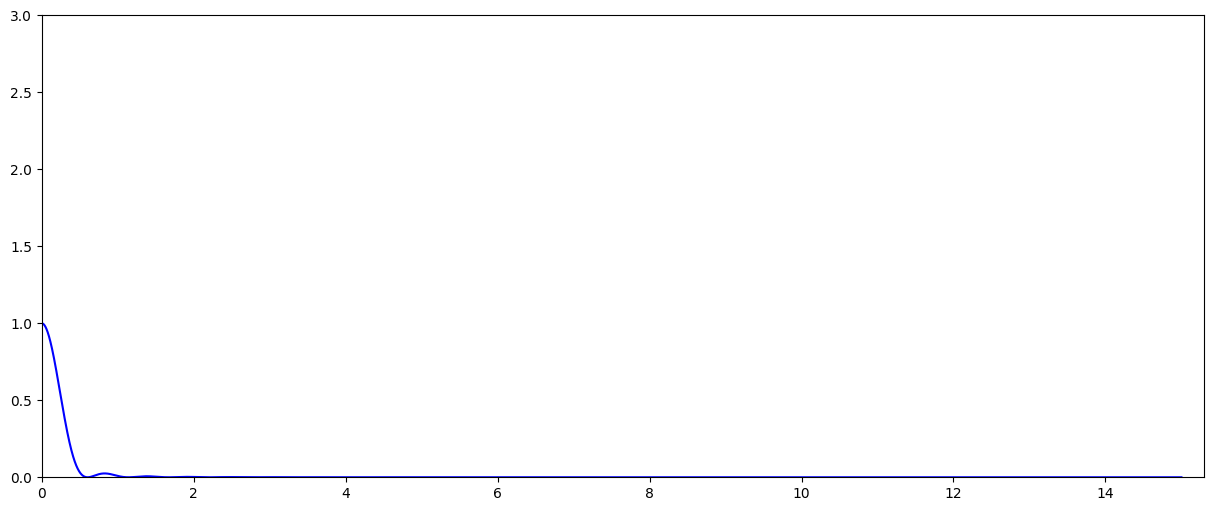

In [6]:
intensity_vec, first_zero_idx, first_zero_mul = zp.field_intensity_calc.calc_intensity(True)
print(f"I0: {intensity_vec[0]}")
print(f"first zero: {first_zero_mul}")
plt.figure(figsize=(15,6))
plt.plot(zp.r_vec, intensity_vec, color="blue")
plt.xlim(0, 15.3)
plt.ylim(0, 3)
plt.savefig("intensity.png", bbox_inches='tight', transparent=True)